# Proyecto 2: Freesound Audio Tagging
## Taller de Aprendizaje Automático 2024
### Nahuel Piñeyro
### Florencia Uslenghi
### Mauricio Vieira


In [ ]:
!pip install -qq comet_ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 677.4/677.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.1/300.1 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.1/979.1 kB 34.7 MB/s eta 0:00:00


In [1]:
!pip install -qq kaggle

In [2]:
!pip install -qq tensorflow_io

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 7.4 MB/s eta 0:00:00


In [3]:
# from comet_ml import Experiment
import tensorflow as tf
import tensorflow_io as tfio
from tensorflow import keras
from keras.models import load_model
from tensorflow.keras import layers
from keras.layers import BatchNormalization
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [41]:
# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [42]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [43]:
tf.config.list_physical_devices('GPU')

[]

In [44]:
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

# El archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# Este archivo se descarga entrando a su perfíl de Kaggle, en la sección API, presionando donde dice: Create New API Token

# uploaded = files.upload()

# for fn in uploaded.keys():
    # print('User uploaded file "{name}" with length {length} bytes'.format(
      # name=fn, length=len(uploaded[fn])))

#Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [45]:
# celda para bajar los datos desde colab
# !kaggle competitions download -c taa-2024-freesound-audio-tagging-v-1
# !unzip /content/taa-2024-freesound-audio-tagging-v-1.zip
# !unzip /content/train_curated.zip
# !unzip /content/train_noisy.zip
# !unzip /content/train_curated_resampled.zip
# !unzip /content/train_noisy_resampled.zip
# !unzip /content/taa-2024-freesound-audio-tagging-v-1.zip "sample_submission_v24.csv"
# !unzip /content/taa-2024-freesound-audio-tagging-v-1.zip "train_curated.csv"
# !unzip /content/taa-2024-freesound-audio-tagging-v-1.zip "train_noisy.csv"
# !unzip /content/taa-2024-freesound-audio-tagging-v-1.zip "vocabulary.csv"

In [46]:
train_curated = pd.read_csv('/content/drive/MyDrive/train_curated.csv')

In [47]:
train_curated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4970 entries, 0 to 4969
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   fname   4970 non-null   object
 1   labels  4970 non-null   object
dtypes: object(2)
memory usage: 77.8+ KB


In [48]:
fnames = train_curated['fname']

In [49]:
# Leer el archivo de audio usando TensorFlow
audio_binary = tf.io.read_file('./train_curated_resampled/'+fnames[0])
waveform, sample_rate = tf.audio.decode_wav(audio_binary)

In [50]:
waveform = tf.squeeze(waveform)

In [51]:
waveform = waveform/tf.reduce_max(tf.abs(waveform))

In [52]:
waveform

<tf.Tensor: shape=(112637,), dtype=float32, numpy=
array([-0.00028043,  0.00056085,  0.00084128, ...,  0.        ,
        0.        ,  0.00028043], dtype=float32)>

In [25]:
# Calculo de la STFT
stft = tf.signal.stft(
waveform,
frame_length = 1024,
frame_step = 512,
window_fn = tf.signal.hann_window,
fft_length = 1024,
)

# Obtener la magnitud de la STFT.
spectrogram = tf.abs(stft)

# Se define el banco de filtros a utilizar
num_spectrogram_bins = stft.shape[-1]
lower_edge_hertz, upper_edge_hertz, num_mel_bins = 0, 4000, 80
linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix (num_mel_bins, num_spectrogram_bins, sample_rate,
lower_edge_hertz,upper_edge_hertz)

# Se aplica el banco de filtros sobre el espectrograma
mel_spectrograms = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
mel_spectrograms.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

# Calculo el Espectrograma en magnitud logaritmica y escala mel
log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)

# Calculo los MFCCs a partir del log_mel_spectrograms y tomo los primeros 13
mfccs = tf.signal.mfccs_from_log_mel_spectrograms(
log_mel_spectrograms)[..., :13]

### Baseline

In [19]:
fnames = train_curated['fname']

In [26]:
def mfccs(waveform, sample_rate):
  # Calculo de la STFT
  stft = tf.signal.stft(
  waveform,
  frame_length = 1024,
  frame_step = 512,
  window_fn = tf.signal.hann_window,
  fft_length = 1024,
  )

  # Obtener la magnitud de la STFT.
  spectrogram = tf.abs(stft)

  # Se define el banco de filtros a utilizar
  num_spectrogram_bins = stft.shape[-1]
  lower_edge_hertz, upper_edge_hertz, num_mel_bins = 0, 4000, 80
  linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix (num_mel_bins, num_spectrogram_bins, sample_rate,
  lower_edge_hertz,upper_edge_hertz)

  # Se aplica el banco de filtros sobre el espectrograma
  mel_spectrograms = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
  mel_spectrograms.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

  # Calculo el Espectrograma en magnitud logaritmica y escala mel
  log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)

  # Calculo los MFCCs a partir del log_mel_spectrograms y tomo los primeros 13
  mfccs = tf.signal.mfccs_from_log_mel_spectrograms(
  log_mel_spectrograms)[..., :13]
  return mfccs, log_mel_spectrograms

In [27]:
def save_rgb_image_as_png(rgb_image, file_path):
    # Convierte el tensor de TensorFlow a un array de numpy
    np_image = rgb_image.numpy()

    # Asegúrate de que los valores estén en el rango [0, 255]
    np_image = (np_image * 255).astype(np.uint8)

    # Crea una imagen PIL
    pil_image = Image.fromarray(np_image)

    # Guarda la imagen
    pil_image.save(file_path, format='PNG')



In [28]:
def spectogram_to_rgb_image(log_mel_spectogram, target_size=(224, 224)):
    # Asegúrate de que el espectrograma tenga la forma correcta
    if len(log_mel_spectogram.shape) == 3 and log_mel_spectogram.shape[1] == 0:
        log_mel_spectogram = log_mel_spectogram[:, 0, :]

    # Normaliza los valores al rango [0, 1]
    normalized = tf.nest.map_structure(tf.dtypes.cast, log_mel_spectogram, tf.float32)
    normalized = (normalized - tf.reduce_min(normalized)) / (tf.reduce_max(normalized) - tf.reduce_min(normalized))

    # Convierte a una representación de color usando una escala de colores
    colored = tf.image.hsv_to_rgb(tf.stack([normalized, tf.ones_like(normalized), tf.ones_like(normalized)], axis=-1))

    # Redimensiona a la forma objetivo
    resized = tf.image.resize(colored, target_size)

    return resized

In [1]:
#rgb_image = spectogram_to_rgb_image(mfccs)

In [ ]:
# Usa la función
#save_rgb_image_as_png(rgb_image, './mfccs_train_curated_resampled/'+fnames[0][:-4]+'.png')

In [ ]:
def imagen(fname):
  for fnames in fname:
    audio = tf.io.read_file('/content/drive/MyDrive/train_curated_resampled/'+fnames)
    waveform, sample_rate = tf.audio.decode_wav(audio)
    waveform = tf.squeeze(waveform)
    waveform = waveform/tf.reduce_max(tf.abs(waveform))
    mfcc, log_mel_spectrograms = mfccs(waveform, sample_rate)
    mfcc = spectogram_to_rgb_image(mfcc, target_size=(224, 224))
    log_mel_spectrograms = spectogram_to_rgb_image(log_mel_spectrograms, target_size=(224, 224))
    save_rgb_image_as_png(mfcc, '/content/drive/MyDrive/mfccs_train_curated_resampled/'+fnames[:-4]+'.png')
    save_rgb_image_as_png(log_mel_spectrograms, '/content/drive/MyDrive/log_mel_train_curated_resampled/'+fnames[:-4]+'.png')

In [ ]:
imagen(fnames)

In [38]:
# # Usa la función
# rgb_image = spectogram_to_rgb_image(mfccs)

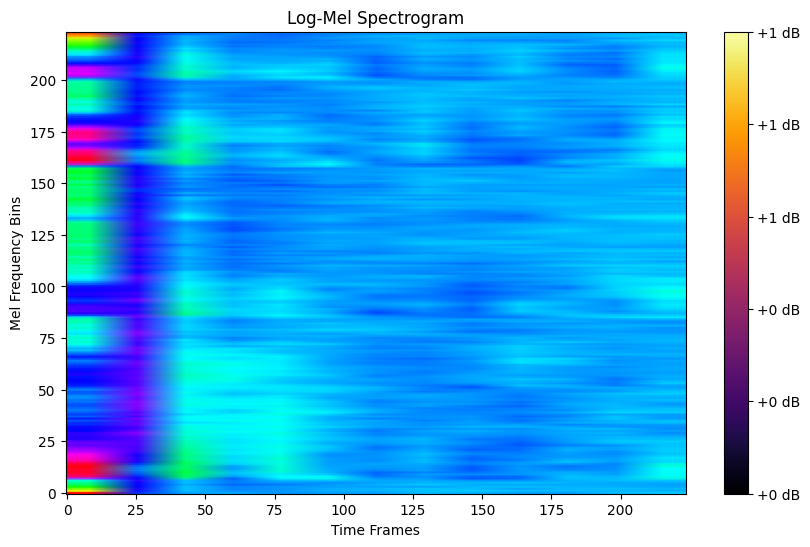

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(rgb_image, aspect='auto', origin='lower', cmap='inferno')
plt.title('Log-Mel Spectrogram')
plt.ylabel('Mel Frequency Bins')
plt.xlabel('Time Frames')
plt.colorbar(format='%+2.0f dB')
plt.show()

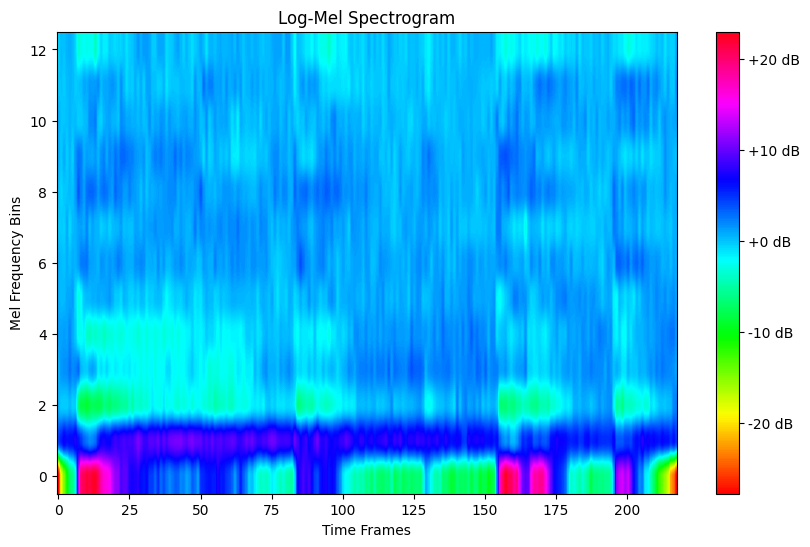

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(mfccs.numpy().T, aspect='auto', origin='lower', cmap='hsv')
plt.title('Log-Mel Spectrogram')
plt.ylabel('Mel Frequency Bins')
plt.xlabel('Time Frames')
plt.colorbar(format='%+2.0f dB')
plt.show()

In [ ]:
norm_layer = layers.Normalization()
norm_layer.adapt(data=mfccs.map(map_func=lambda spec, label: spec))

In [ ]:
# Instantiates the MobileNet architecture con sus valores originales
MobileNet = keras.applications.MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001,
    include_top=True,
    weights='imagenet',
    input_tensor=None,
    pooling=None,
    classes=80,
    classifier_activation='softmax'
)

In [ ]:
# todo MN
model_MobileNet = tf.keras.Sequential([
    norm_layer,
    MobileNet
])

In [ ]:
MobileNet1 = keras.applications.MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001,
    include_top=False,
    weights='imagenet'
)

In [ ]:
model_MobileNet1 = tf.keras.Sequential([
    norm_layer,
    MobileNet1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(80, activation='softmax')
])

In [ ]:
# Test
#!unzip /content/test.zip
#!unzip /content/test_resampled.zip

### Prueba espectrograma del ejemplo de TF:

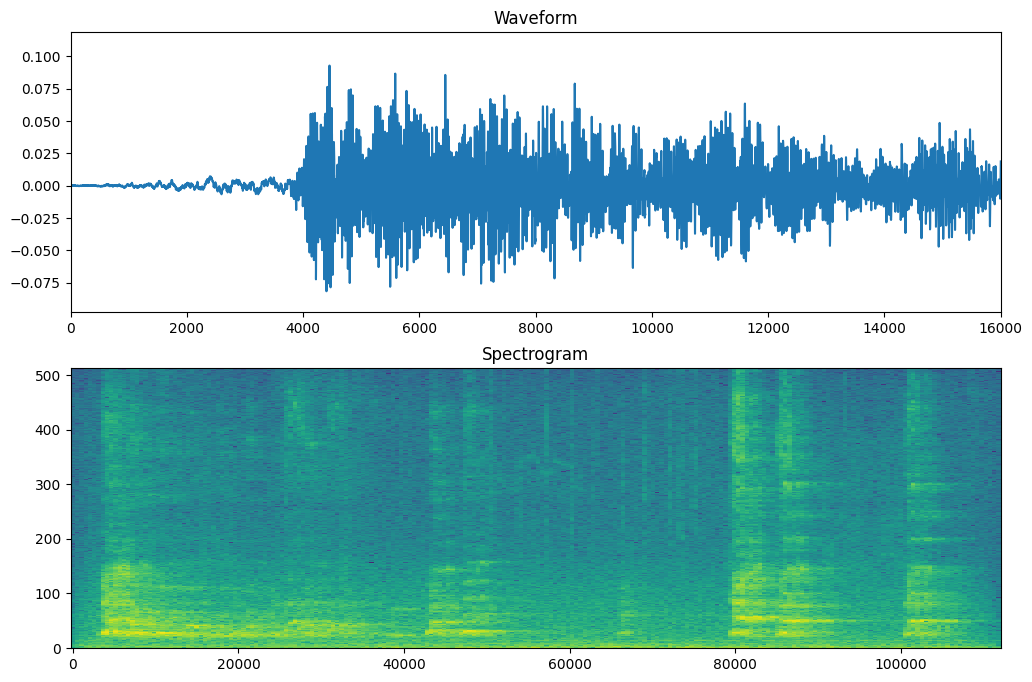

In [36]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)


audio_binary = tf.io.read_file('./train_curated_resampled/'+fnames[0])
waveform, sample_rate = tf.audio.decode_wav(audio_binary)

fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

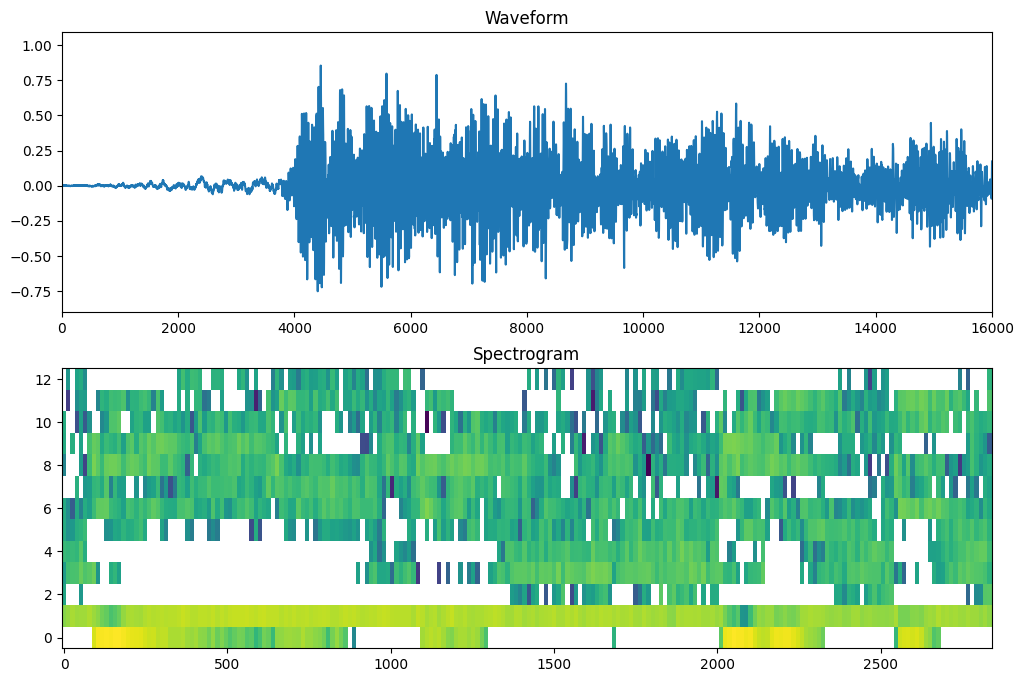

In [53]:
def plot_spectrogram_mfcc(mfccs):
    fig, ax = plt.subplots(figsize=(12, 6))
    img = ax.pcolormesh(np.arange(mfccs.shape[0] + 1), np.arange(mfccs.shape[1] + 1), mfccs.T, shading='flat')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_ylabel('MFCC Coefficients')
    ax.set_xlabel('Time')
    ax.set_title('MFCC')
    plt.show()

def compute_mfccs(waveform, sample_rate):
    stft = tf.signal.stft(
        waveform,
        frame_length=1024,
        frame_step=512,
        window_fn=tf.signal.hann_window,
        fft_length=1024,
    )

    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]
    lower_edge_hertz, upper_edge_hertz, num_mel_bins = 0, 4000, 80
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins, num_spectrogram_bins, sample_rate,
        lower_edge_hertz, upper_edge_hertz)

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)

    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(
        log_mel_spectrogram)[..., :13]

    return mfccs

audio_file = './train_curated_resampled/' + fnames[0]  
audio_binary = tf.io.read_file(audio_file)
waveform, sample_rate = tf.audio.decode_wav(audio_binary)

waveform = tf.squeeze(waveform)
waveform /= tf.reduce_max(tf.abs(waveform))

mfccs = compute_mfccs(waveform, sample_rate)

plot_spectrogram_mfcc(mfccs.numpy())